In [1]:
library(dplyr)
library(parallel)
library(ArchR)
library(RColorBrewer)
library(cowplot)

addArchRGenome("hg38")
set.seed(1)

library(Cairo)
CairoFonts(
  regular = "sans:style=Regular",
  bold = "sans:style=Bold",
  italic = "sans:style=Italic",
  bolditalic = "sans:style=Bold Italic,BoldItalic",
  symbol = "Symbol", usePUA = TRUE
)

addArchRThreads(threads = 10) 


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __

In [2]:
frag_files <- c(
  list.files(
    path = "../20241120/singlecell/no_error/mapping",
    pattern = "_duprm_phased_HP.*_flank.bed.gz$", full.names = TRUE
  ),
  list.files(
    path = "../20241115/no_error/mapping",
    pattern = "_duprm_phased_HP.*_flank.bed.gz$", full.names = TRUE
  )
)


In [3]:
frag_files

[1] "../20241120/singlecell/no_error/mapping/GM12878_duprm_phased_HP1_flank.bed.gz"
[2] "../20241120/singlecell/no_error/mapping/GM12878_duprm_phased_HP2_flank.bed.gz"
[3] "../20241115/no_error/mapping/B51_duprm_phased_HP1_flank.bed.gz"               
[4] "../20241115/no_error/mapping/B51_duprm_phased_HP2_flank.bed.gz"

In [4]:
names(frag_files) <- c("GM12878_Paternal", "GM12878_Maternal", "Mix_GM12878_Paternal", "Mix_GM12878_Maternal")

In [11]:
frag <- lapply(names(frag_files), function(x) {
  df <- read.table(frag_files[[x]])
  colnames(df) <- c("chrom", "start", "end", "barcode", "mapq", "strand")
  df$file <- x
  df$Sample <- gsub("_[PM]aternal","",x)
  df$haplotype <- gsub(".*_","",x)
  return(df)
}) %>% do.call(rbind,.)

In [16]:
frag$id <- paste(frag$Sample,frag$barcode,sep = "#")

In [15]:
unique(frag$Sample)

[1] "GM12878"     "Mix_GM12878"

In [6]:
proj <- loadArchRProject(path = './GM12878_merged_noerror')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [12]:
cell_used <- rownames(proj@cellColData)

In [17]:
head(frag)

,chrom,start,end,barcode,mapq,strand,file,Sample,haplotype,id
,<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1,767867,767868,CGATAGGCACTCATACTCTG,35,-,GM12878_Paternal,GM12878,Paternal,GM12878#CGATAGGCACTCATACTCTG
2,chr1,771411,771412,CGATAGGCACTCATACTCTG,35,-,GM12878_Paternal,GM12878,Paternal,GM12878#CGATAGGCACTCATACTCTG
3,chr1,768321,768322,CCTAGGAGCGATACCTATAT,48,-,GM12878_Paternal,GM12878,Paternal,GM12878#CCTAGGAGCGATACCTATAT
4,chr1,775021,775022,CCTAGGAGCGATACCTATAT,48,-,GM12878_Paternal,GM12878,Paternal,GM12878#CCTAGGAGCGATACCTATAT
5,chr1,768865,768866,CACTCGAGTGGGTATGTGGA,55,-,GM12878_Paternal,GM12878,Paternal,GM12878#CACTCGAGTGGGTATGTGGA
6,chr1,776028,776029,CACTCGAGTGGGTATGTGGA,55,-,GM12878_Paternal,GM12878,Paternal,GM12878#CACTCGAGTGGGTATGTGGA


In [18]:
frag_flt <- frag[frag$id %in% cell_used, ]

In [19]:
peak_set <- proj@peakSet

In [21]:
length(peak_set)

[1] 67271

In [26]:
library(gUtils)
frag_gr <- dt2gr(frag_flt)

Warning message in dt2gr(frag_flt):
“Warning: Coercing to GRanges via non-standard columns”


In [5]:
frag_gr <- frag_gr %>% reset_seqlen()

In [6]:
frag_slop <- resize(frag_gr, fix = 'center',width = 150)

In [9]:
frag_slop$id <- paste(frag_slop$ID, frag_slop$barcode, sep = "_")

In [14]:
write.table(as.data.frame(frag_slop[frag_slop$haplotype == "Paternal"])[,c("seqnames","start","end","id","mapq","strand")],
"./GM12878_merged_noerror/Results/GM12878_merged_paternal_fragments_slop.bed", row.names = F, col.names = F, quote = F, sep = '\t')
write.table(as.data.frame(frag_slop[frag_slop$haplotype == "Maternal"])[,c("seqnames","start","end","id","mapq","strand")],
"./GM12878_merged_noerror/Results/GM12878_merged_maternal_fragments_slop.bed", row.names = F, col.names = F, quote = F, sep = '\t')

In [29]:
ov <- frag_gr %*% peak_set

Warning message in gr.findoverlaps(x, y, qcol = names(values(x)), scol = names(values(y))):
“findOverlaps applied to ranges with non-identical seqlengths”


In [33]:
ov$id <- paste(ov$ID, ov$barcode, sep = "#")

In [34]:
ov

GRanges object with 1778569 ranges and 20 metadata columns:
            seqnames              ranges strand |  query.id subject.id
               <Rle>           <IRanges>  <Rle> | <integer>  <integer>
        [1]     chr1       804750-804751      * |   3100681          1
        [2]     chr1       804811-804812      * |   3100683          1
        [3]     chr1       804830-804831      * |        13          1
        [4]     chr1       804839-804840      * |   3100685          1
        [5]     chr1       804845-804846      * |   3100687          1
        ...      ...                 ...    ... .       ...        ...
  [1778565]     chrX 155233956-155233957      * |   8702479      67269
  [1778566]     chrX 155233956-155233957      * |  11205669      67269
  [1778567]     chrX 155233956-155233957      * |  11205671      67269
  [1778568]     chrX 155233956-155233957      * |  11205673      67269
  [1778569]     chrX 155234025-155234026      * |   3100639      67269
                 

In [38]:
asp_counts <- ov %>%
    as.data.frame() %>%
    dplyr::group_by(subject.id, haplotype) %>%
    dplyr::summarise(
      ncell = n_distinct(id),
      nfrags = length(id)
    )

`summarise()` has grouped output by 'subject.id'. You can override using the
`.groups` argument.


In [39]:
head(asp_counts)

subject.id,haplotype,ncell,nfrags
<int>,<chr>,<int>,<int>
1,Maternal,15,16
1,Paternal,13,16
11,Maternal,23,24
11,Paternal,18,18
12,Maternal,32,34
12,Paternal,29,30


In [40]:
asp_counts_df <- full_join(asp_counts[asp_counts$haplotype == "Paternal",c(1,3,4)],
  asp_counts[asp_counts$haplotype == "Maternal",c(1,3,4)],
  suffix = c("_pat", "_mat"), by = "subject.id"
)


In [41]:
head(asp_counts_df)

subject.id,ncell_pat,nfrags_pat,ncell_mat,nfrags_mat
<int>,<int>,<int>,<int>,<int>
1,13,16,15,16
11,18,18,23,24
12,29,30,32,34
13,14,15,9,10
14,15,17,14,17
15,5,6,10,11


In [42]:
asp_counts_df$total_frags <- asp_counts_df$nfrags_pat + asp_counts_df$nfrags_mat
asp_counts_df$pat_ratio <- asp_counts_df$nfrags_pat/(asp_counts_df$nfrags_pat + asp_counts_df$nfrags_mat)

In [43]:
head(asp_counts_df)

subject.id,ncell_pat,nfrags_pat,ncell_mat,nfrags_mat,total_frags,pat_ratio
<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
1,13,16,15,16,32,0.5000000
11,18,18,23,24,42,0.4285714
12,29,30,32,34,64,0.4687500
13,14,15,9,10,25,0.6000000
14,15,17,14,17,34,0.5000000
15,5,6,10,11,17,0.3529412


Warning message:
“Removed 3097 rows containing non-finite outside the scale range
(`stat_pointdensity()`).”


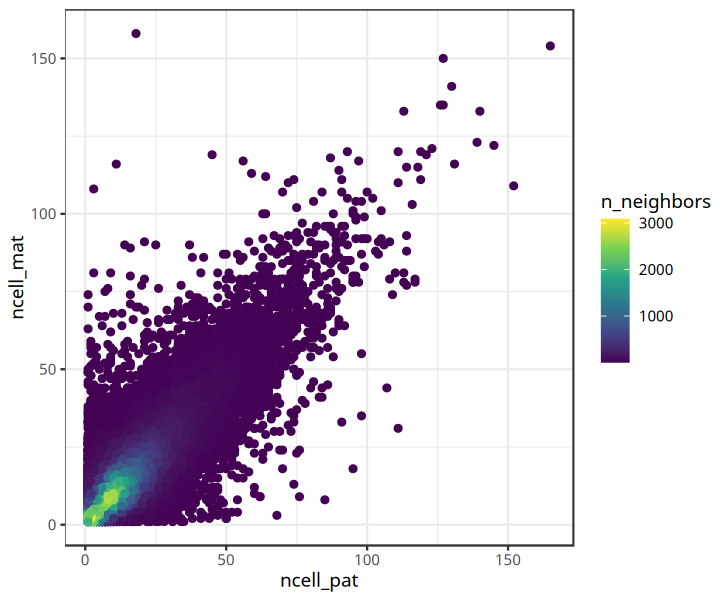

In [44]:
library(ggpointdensity)
options(repr.plot.width = 6, repr.plot.height = 5)

ggplot(asp_counts_df, aes(x = ncell_pat, y = ncell_mat)) +
geom_pointdensity() +
scale_color_viridis_c() +
theme_bw()

Warning message:
“Removed 3097 rows containing non-finite outside the scale range
(`stat_pointdensity()`).”


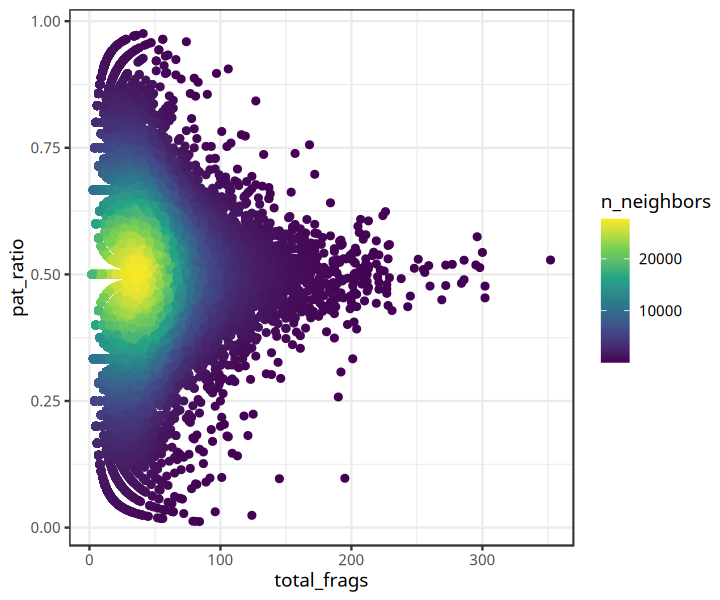

In [45]:
ggplot(asp_counts_df, aes(x = total_frags, y = pat_ratio)) +
  geom_pointdensity() +
  scale_color_viridis_c() +
  theme_bw()


In [47]:
asp_counts_df$p_value <- apply(asp_counts_df, 1, function(x) {
  pat <- x[3]
  mat <- x[5]
  if (!is.na(mat) & !is.na(pat)) {
    res <- binom.test(c(mat, pat), p = 0.5)
    return(res$p.value)
  } else {
    return(NA)
  }
})


In [48]:
asp_counts_df$fdr <- p.adjust(asp_counts_df$p_value, method = "BH")

In [49]:
asp_counts_df$significance <- "N.S."
try(asp_counts_df[!is.na(asp_counts_df$fdr) & asp_counts_df$fdr < 0.05, ]$significance <- "*", silent = T)
try(asp_counts_df[!is.na(asp_counts_df$fdr) & asp_counts_df$fdr < 0.01, ]$significance <- "**", silent = T)
try(asp_counts_df[!is.na(asp_counts_df$fdr) & asp_counts_df$fdr < 0.001, ]$significance <- "***", silent = T)
asp_counts_df$significance <- factor(asp_counts_df$significance, levels = c("N.S.","*","**","***"))

In [50]:
asp_counts_df$type <- "none"
asp_counts_df[!is.na(asp_counts_df$pat_ratio) & asp_counts_df$pat_ratio > 0.5, ]$type <- "pat"
asp_counts_df[!is.na(asp_counts_df$pat_ratio) & asp_counts_df$pat_ratio < 0.5, ]$type <- "mat"
asp_counts_df[!is.na(asp_counts_df$pat_ratio) & asp_counts_df$significance == "N.S.",]$type <- "none"

In [51]:
table(asp_counts_df$significance)


 N.S.     *    **   *** 
52609   510   301   369 

In [52]:
table(asp_counts_df[,c("type","significance")])

      significance
type    N.S.     *    **   ***
  mat      0   297   168   251
  none 52609     0     0     0
  pat      0   213   133   118

In [53]:
nrow(asp_counts_df[!is.na(asp_counts_df$fdr) & asp_counts_df$fdr < 0.05,])

[1] 1180

In [54]:
min(asp_counts_df[!is.na(asp_counts_df$fdr) & asp_counts_df$fdr < 0.05,]$total_frags)

[1] 15

In [56]:
head(as.data.frame(peak_set))

,seqnames,start,end,width,strand,score,replicateScoreQuantile,groupScoreQuantile,Reproducibility,GroupReplicate,distToGeneStart,nearestGene,peakType,distToTSS,nearestTSS,GC,idx
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<dbl>,<int>
1,chr1,804670,805170,501,*,27.83830,0.912,0.911,2,GM12878._.GM12878,12450,FAM87B,Distal,11,uc057awz.1,0.4032,1319
2,chr1,826462,826962,501,*,4.74080,0.385,0.403,2,GM12878._.Other,809,LINC00115,Exonic,119,uc057axb.1,0.4711,5828
3,chr1,827788,828288,501,*,14.37170,0.777,0.780,2,GM12878._.GM12878,515,LINC00115,Promoter,216,uc057axi.1,0.5629,3021
4,chr1,857855,858355,501,*,12.34520,0.800,0.801,2,GM12878._.Other,18797,FAM41C,Exonic,6756,uc057axk.1,0.3812,2778
5,chr1,865523,866023,501,*,3.65692,0.228,0.244,2,GM12878._.Other,11129,FAM41C,Distal,4427,uc057axl.1,0.4671,6292
6,chr1,867313,867813,501,*,7.09235,0.600,0.612,2,GM12878._.Other,9339,FAM41C,Distal,2637,uc057axl.1,0.4571,4631


In [58]:
peak_set$idx <- 1:length(peak_set)
asp_counts_df <- left_join(asp_counts_df,as.data.frame(peak_set)[,c("seqnames","start","end","idx","peakType","distToTSS","nearestGene","Reproducibility")], by = c("subject.id" = "idx"))

In [59]:
head(asp_counts_df)

subject.id,ncell_pat,nfrags_pat,ncell_mat,nfrags_mat,total_frags,pat_ratio,p_value,fdr,significance,type,seqnames,start,end,peakType,distToTSS,nearestGene,Reproducibility
<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<fct>,<int>,<int>,<chr>,<int>,<chr>,<int>
1,13,16,15,16,32,0.5000000,1.0000000,1.0000000,N.S.,none,chr1,804670,805170,Distal,11,FAM87B,2
11,18,18,23,24,42,0.4285714,0.4407991,0.9929485,N.S.,none,chr1,3618908,3619408,Distal,5584,TPRG1L,2
12,29,30,32,34,64,0.4687500,0.7079808,1.0000000,N.S.,none,chr1,3621103,3621603,Distal,3389,TPRG1L,2
13,14,15,9,10,25,0.6000000,0.4243562,0.9773052,N.S.,none,chr1,3655849,3656349,Intronic,3337,WRAP73,2
14,15,17,14,17,34,0.5000000,1.0000000,1.0000000,N.S.,none,chr1,3660605,3661105,Intronic,7916,WRAP73,2
15,5,6,10,11,17,0.3529412,0.3323059,0.9229263,N.S.,none,chr1,3747227,3747727,Promoter,140,TP73-AS1,2


Warning message:
“Removed 3097 rows containing missing values or values outside the scale range
(`geom_point()`).”


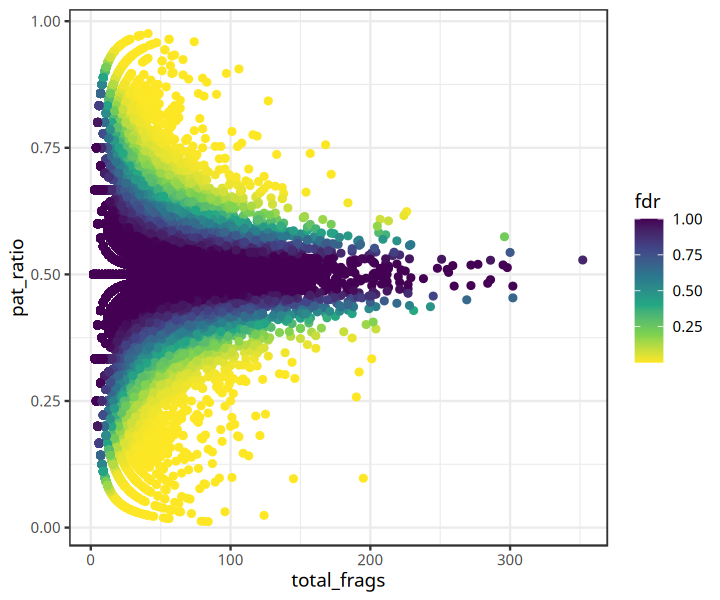

In [60]:
ggplot(asp_counts_df, aes(x = total_frags, y = pat_ratio)) +
  geom_point(aes(color = fdr)) +
  scale_color_viridis_c(direction = -1) +
  theme_bw()

Warning message:
“Removed 3097 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3097 rows containing missing values or values outside the scale range
(`geom_point()`).”


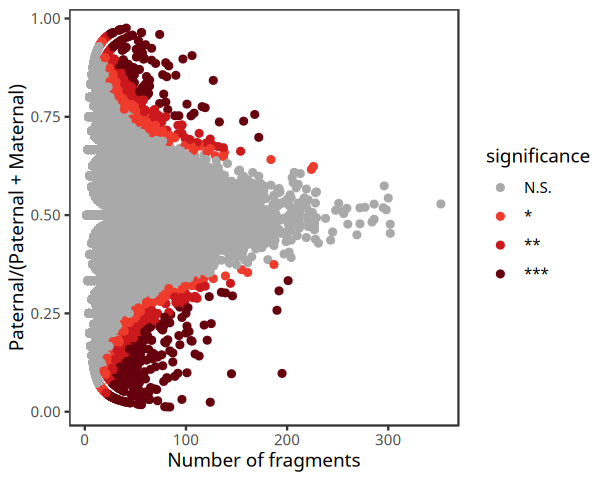

In [61]:
options(repr.plot.width = 5, repr.plot.height = 4)

p <- ggplot(asp_counts_df, aes(x = total_frags, y = pat_ratio)) +
  geom_point(aes(color = significance)) +
  scale_color_manual(values = c("darkgrey",brewer.pal(9,"Reds")[c(6,7,9)])) +
  theme_bw() +
  xlab("Number of fragments") +
  ylab("Paternal/(Paternal + Maternal)") +
  theme(panel.grid = element_blank())

save_plot("./GM12878_merged_noerror/Results/GM12878_allelic_peaks_scatterplot.pdf", p, base_height = 4, base_width = 5)
p

In [62]:
asp_counts_df$type <- factor(asp_counts_df$type, levels = c("none","mat","pat"))

In [63]:
library(ggrastr)

Warning message:
“Removed 3097 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3097 rows containing missing values or values outside the scale range
(`geom_point()`).”


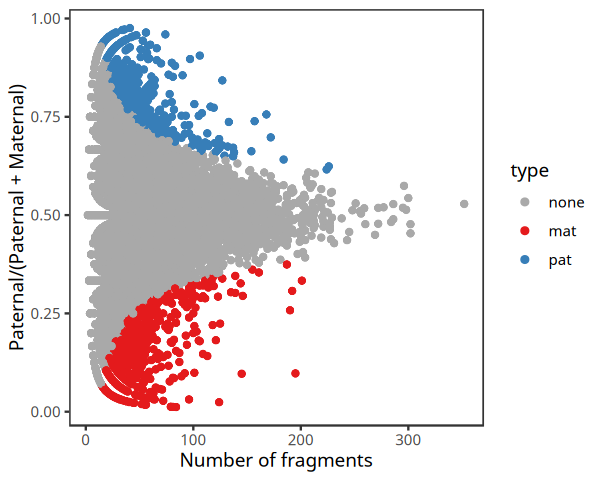

In [64]:
options(repr.plot.width = 5, repr.plot.height = 4)

p <- ggplot(asp_counts_df, aes(x = total_frags, y = pat_ratio)) +
  geom_point_rast(aes(color = type)) +
  scale_color_manual(values = c("darkgrey",brewer.pal(9,"Set1")[c(1,2)])) +
  theme_bw() +
  xlab("Number of fragments") +
  ylab("Paternal/(Paternal + Maternal)") +
  theme(panel.grid = element_blank())

save_plot("./GM12878_merged_noerror/Results/GM12878_allelic_peaks_colorByType_scatterplot.pdf", p, base_height = 4, base_width = 5)
p

In [81]:
asp_df <- asp_counts_df[!is.na(asp_counts_df$fdr) & asp_counts_df$fdr < 0.05,] %>% droplevels()

In [67]:
total_pk_sum <- table(as.data.frame(peak_set)$seqnames) %>% 
as.data.frame() %>%
mutate(Var1 = factor(Var1, levels = paste0("chr",c(1:22,"X")))) %>%
`colnames<-`(c("chrom","npeaks"))

In [82]:
library(tidyr)
asp_chr_sum <- table(asp_df[,c("seqnames","type")]) %>% 
as.data.frame() %>%
spread(type, Freq) %>%
mutate(nASP = pat + mat) %>%
mutate(seqnames = factor(seqnames, levels = paste0("chr",c(1:22,"X")))) %>%
arrange(seqnames)

In [83]:
asp_chr_sum <- left_join(asp_chr_sum,total_pk_sum, by = c("seqnames" = "chrom"))

In [84]:
asp_chr_sum$ASP_ratio <- asp_chr_sum$nASP/asp_chr_sum$npeaks
asp_chr_sum$pASP_ratio <- asp_chr_sum$pat/asp_chr_sum$npeaks
asp_chr_sum$mASP_ratio <- asp_chr_sum$mat/asp_chr_sum$npeaks

In [3]:
head(asp_chr_sum)

,seqnames,mat,pat,nASP,npeaks,ASP_ratio,pASP_ratio,mASP_ratio
,<fct>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,chr1,52,43,95,6550,0.01450382,0.006564885,0.007938931
2,chr2,89,53,142,5831,0.02435260,0.009089350,0.015263248
3,chr3,21,35,56,5026,0.01114206,0.006963788,0.004178273
4,chr4,18,37,55,4200,0.01309524,0.008809524,0.004285714
5,chr5,44,46,90,4164,0.02161383,0.011047070,0.010566763
6,chr6,39,39,78,4975,0.01567839,0.007839196,0.007839196


In [4]:
asp_chr_sum_m <- melt(asp_chr_sum[,c(1,6:8)])

Warning message in melt.default(asp_chr_sum[, c(1, 6:8)]):
“The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is superseded and is no longer actively developed, and this redirection is now deprecated. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace, i.e. reshape2::melt(asp_chr_sum[, c(1, 6:8)]). In the next version, this warning will become an error.”
Using seqnames as id variables



In [5]:
unique(asp_chr_sum_m$variable)

[1] ASP_ratio  pASP_ratio mASP_ratio
Levels: ASP_ratio pASP_ratio mASP_ratio


Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




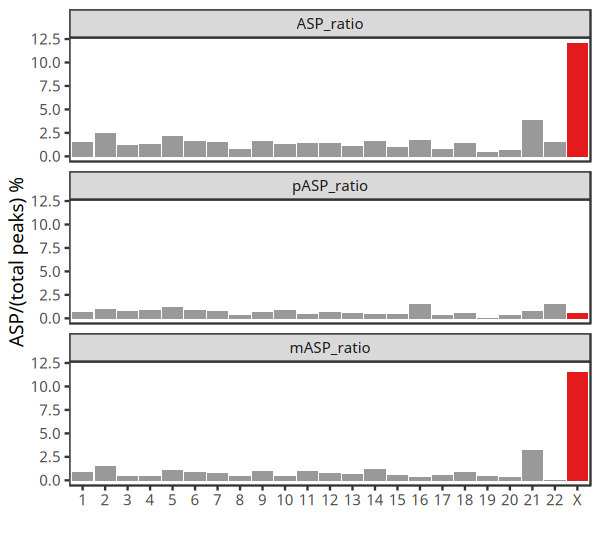

In [6]:
library(patchwork)
options(repr.plot.width = 5, repr.plot.height = 4.5)
p1 <- ggplot(asp_chr_sum_m, aes(x = seqnames, y = value * 100)) +
  geom_col(aes(fill = seqnames == "chrX")) +
  facet_wrap(vars(variable), ncol = 1) +
  theme_bw() +
  xlab("") +
  ylab("ASP/(total peaks) %") +
  scale_fill_manual("", values = brewer.pal(9, "Set1")[c(9, 1)]) +
  scale_x_discrete(label = c(1:22, "X")) +
  theme(
    panel.grid = element_blank(),
    legend.position = "none"
  )

save_plot("./GM12878_merged_noerror/Results/GM12878_ASP_chrom_summary.pdf", p1, base_height = 4.5, base_width = 5)
p1

In [9]:
tail(asp_counts_df)

subject.id,ncell_pat,nfrags_pat,ncell_mat,nfrags_mat,total_frags,pat_ratio,p_value,fdr,significance,type,seqnames,start,end,peakType,distToTSS,nearestGene,Reproducibility
<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<int>,<chr>,<int>,<chr>,<int>
67227,NA,NA,8,9,NA,NA,NA,NA,N.S.,none,chrX,149987581,149988081,Intronic,26949,CXorf40B,2
67229,NA,NA,3,3,NA,NA,NA,NA,N.S.,none,chrX,150569047,150569547,Intronic,657,MTM1,2
67230,NA,NA,3,3,NA,NA,NA,NA,N.S.,none,chrX,150570478,150570978,Intronic,2088,MTM1,2
67233,NA,NA,25,25,NA,NA,NA,NA,N.S.,none,chrX,150574812,150575312,Intronic,6422,MTM1,2
67257,NA,NA,2,2,NA,NA,NA,NA,N.S.,none,chrX,154827491,154827991,Intronic,282,MPP1,2
67260,NA,NA,2,2,NA,NA,NA,NA,N.S.,none,chrX,154987166,154987666,Intronic,20899,FUNDC2,2


In [13]:
asp_counts_flt <- asp_counts_df %>% 
filter(type != "none") %>%
mutate(strand = ".") %>%
ungroup %>%
select(seqnames,start,end,type,pat_ratio,strand)

In [15]:
write.table(asp_counts_flt[asp_counts_flt$type == "pat",],'./GM12878_merged_noerror/Results/GM12878_ASP_paternal.bed',row.names = F,col.names = T,sep = '\t',quote = F)
write.table(asp_counts_flt[asp_counts_flt$type == "mat",],'./GM12878_merged_noerror/Results/GM12878_ASP_maternal.bed',row.names = F,col.names = T,sep = '\t',quote = F)

In [4]:
dim(asp_counts_df)

[1] 53789    18

In [7]:
head(asp_counts_df)

subject.id,ncell_pat,nfrags_pat,ncell_mat,nfrags_mat,total_frags,pat_ratio,p_value,fdr,significance,type,seqnames,start,end,peakType,distToTSS,nearestGene,Reproducibility
<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<int>,<chr>,<int>,<chr>,<int>
1,13,16,15,16,32,0.5000000,1.0000000,1.0000000,N.S.,none,chr1,804670,805170,Distal,11,FAM87B,2
11,18,18,23,24,42,0.4285714,0.4407991,0.9929485,N.S.,none,chr1,3618908,3619408,Distal,5584,TPRG1L,2
12,29,30,32,34,64,0.4687500,0.7079808,1.0000000,N.S.,none,chr1,3621103,3621603,Distal,3389,TPRG1L,2
13,14,15,9,10,25,0.6000000,0.4243562,0.9773052,N.S.,none,chr1,3655849,3656349,Intronic,3337,WRAP73,2
14,15,17,14,17,34,0.5000000,1.0000000,1.0000000,N.S.,none,chr1,3660605,3661105,Intronic,7916,WRAP73,2
15,5,6,10,11,17,0.3529412,0.3323059,0.9229263,N.S.,none,chr1,3747227,3747727,Promoter,140,TP73-AS1,2


In [8]:
write.table(asp_counts_df[asp_counts_df$type != "none",],'./GM12878_merged_noerror/Results/GM12878_ASP_all_info.txt',row.names = F,col.names = T,sep = '\t',quote = F)

In [120]:
save.image('./GM12878_merged_noerror/GM12878_allelic.RData')